Extra Lab Work based On FashionMnist

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
#Load fashion_mnist dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
#To Correctly input the data into the model
print(x_train.shape) 
print(y_train.shape)  
print(x_test.shape)   
print(y_test.shape)   

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
img_rows, img_cols = 28, 28
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test  = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)

In [5]:
#Convert class vectors to binary class matrices (one-hot encoding)


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
#Define ALexNet model in Keras
from tensorflow.keras.layers import Dropout
input_shape =(28,28,1)
num_classes = 10
model = models.Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

In [7]:
#compile the model
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                   

In [9]:
#--model architecture
tf.keras.utils.plot_model(model,show_layer_names=True,show_shapes=True,show_dtype=False)

AttributeError: module 'pydot' has no attribute 'InvocationException'

In [10]:
#Create data Augmentation generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    width_shift_range = 0.1 , #randomly shift images Horizontally
    height_shift_range = 0.1, #Randomly Shift images Vertically
    horizontal_flip = True #randomly flip images Horizontally
)

In [11]:
datagen.fit(x_train)

In [12]:
#Train Model 
history = model.fit(datagen.flow(x_train,y_train,batch_size=64),
                            epochs = 10,
                            validation_data = (x_test,y_test),
                            verbose = 1)

Epoch 1/10


938/938 [==============================] - 23s 23ms/step - loss: 0.6849 - accuracy: 0.7662 - val_loss: 0.4117 - val_accuracy: 0.8504
Epoch 2/10
938/938 [==============================] - 21s 23ms/step - loss: 0.4398 - accuracy: 0.8400 - val_loss: 0.3571 - val_accuracy: 0.8656
Epoch 3/10
938/938 [==============================] - 21s 22ms/step - loss: 0.3884 - accuracy: 0.8571 - val_loss: 0.3090 - val_accuracy: 0.8884
Epoch 4/10
938/938 [==============================] - 21s 22ms/step - loss: 0.3572 - accuracy: 0.8684 - val_loss: 0.2879 - val_accuracy: 0.8950
Epoch 5/10
938/938 [==============================] - 21s 22ms/step - loss: 0.3402 - accuracy: 0.8749 - val_loss: 0.2891 - val_accuracy: 0.8939
Epoch 6/10
938/938 [==============================] - 21s 22ms/step - loss: 0.3246 - accuracy: 0.8799 - val_loss: 0.2841 - val_accuracy: 0.8991
Epoch 7/10
938/938 [==============================] - 21s 22ms/step - loss: 0.3157 - accuracy: 0.8839 - val_loss: 0.2850 - val_accurac

In [ ]:
#Evaluate The Model
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f'Test Accuracy:{test_acc}')

313/313 - 3s - 8ms/step - accuracy: 0.8218 - loss: 0.4569
Test Accuracy:0.8217999935150146


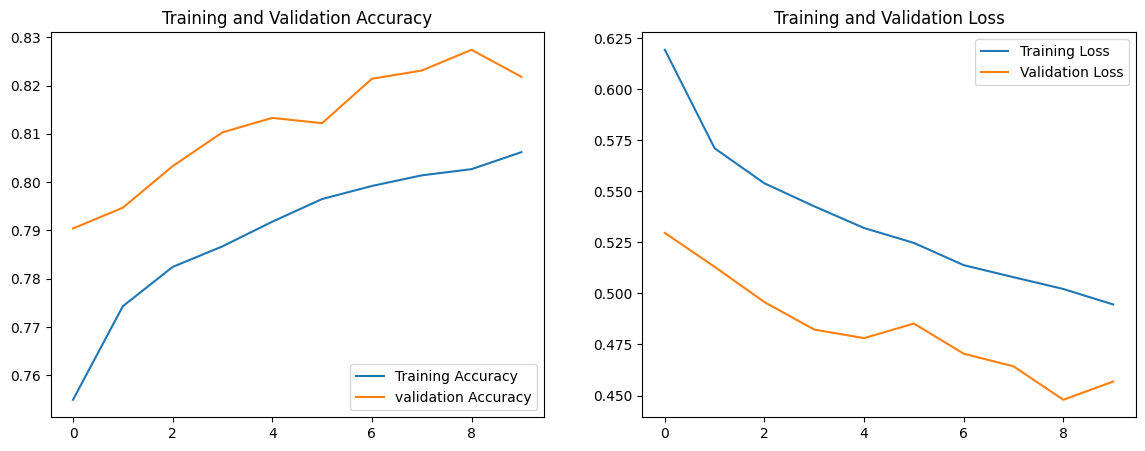

In [ ]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./Classwork1.png')
plt.show()
